In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os 
from data_loading import load_runs
from microfit.histogram import Binning, Histogram, RunHistGenerator

# MCC9
# RUN = ["4a"]
# RUN = ["4b"]
# RUN = ["4c"]
# RUN = ["4d"]
# RUN = ["5"]
RUN = ["4a", "4b", "4c", "4d", "5"]
rundata, mc_weights, data_pot = load_runs(
    RUN,
    data="bnb",
    truth_filtered_sets=["nue", "drt"],
    loadpi0variables=True,
    loadshowervariables=True, # Loads in all variables we might want, including BDT variables (use_bdt=True asserts that these variables are loaded)
    loadrecoveryvars=True,
    loadsystematics=False,    # Set to false when we don't have event weights
    load_crt_vars=True,
    loadnumuvariables=True,
    use_bdt = True,    
    load_lee=False,
    enable_cache=True,
    blinded=True,             # Set blinded to true, no training on data!!
)

Loading run 4a
Loading run 4b
Loading run 4c
Loading run 4d
Loading run 5


In [3]:
shower_energy = [
    ("shr_energy_tot_cali", 10, (0, 4.0), "shr_energy_tot_cali"),
    ("shr_energy_tot_cali", 10, (0, 1), "shr_energy_tot_cali")
]

nslice_var = [
    ("nslice", 1, (0, 2), "nslice"),
]

In [4]:
varSet = shower_energy
# varSet = nslice_var

In [7]:
# preselection = 'None'
preselection = 'NUE'
# preselection = 'ZP'
# preselection = 'ZPCRT'
# preselection = 'NP'

selection = 'None'
# selection = 'ZPLOOSESEL'
# selection = 'bdtsomething'

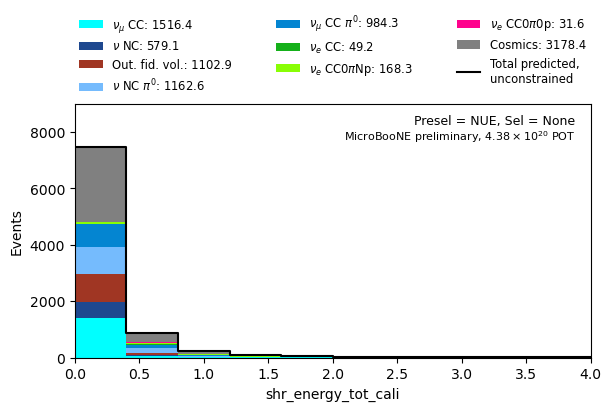

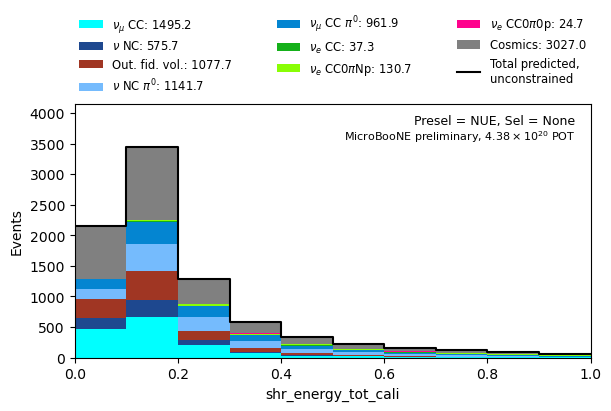

In [8]:
for v in varSet:
    binning_def = v
    binning = Binning.from_config(*binning_def)
    binning.label = preselection
    binning.set_selection(selection, preselection)

    signal_generator = RunHistGenerator(
        rundata,
        binning,
        data_pot=data_pot,
    )

    from microfit.run_plotter import RunHistPlotter

    plotter = RunHistPlotter(signal_generator)

    # Blinded
    ax = plotter.plot(
        category_column="category",
        include_multisim_errors=False,
        add_ext_error_floor=False,
        show_data_mc_ratio=False,
        show_chi_square=False,
        show_total=False,           # Get rid of uncertainty
        title=f'Presel = {binning.preselection_key}, Sel = {binning.selection_key}'
    )